first best

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SequentialFeatureSelector, VarianceThreshold
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Chargement
df = pd.read_csv("parkinson.csv")

# Séparation
X = df.drop(columns=["ID", "Recording", "Status"])
y = df["Status"]

# Encodage du genre si nécessaire
if "Gender" in X.columns:
    X = pd.get_dummies(X, columns=["Gender"], drop_first=True)

# Supprimer colonnes quasi constantes
X = VarianceThreshold(threshold=1e-6).fit_transform(X)

# Normalisation robuste
scaler = PowerTransformer(method='yeo-johnson')
X_scaled = scaler.fit_transform(X)



Nombre de features sélectionnées : 22

Résumé des performances :


,Classifier,Accuracy,Precision,Recall,F1-score
0,Naïve Bayes,0.825,0.831,0.817,0.824
1,c-SVM,0.825,0.855,0.783,0.817
2,nu-SVM,0.838,0.858,0.808,0.833
3,MLP,0.787,0.805,0.758,0.781
4,KNN,0.808,0.819,0.792,0.805
5,Random Forest,0.812,0.844,0.767,0.803


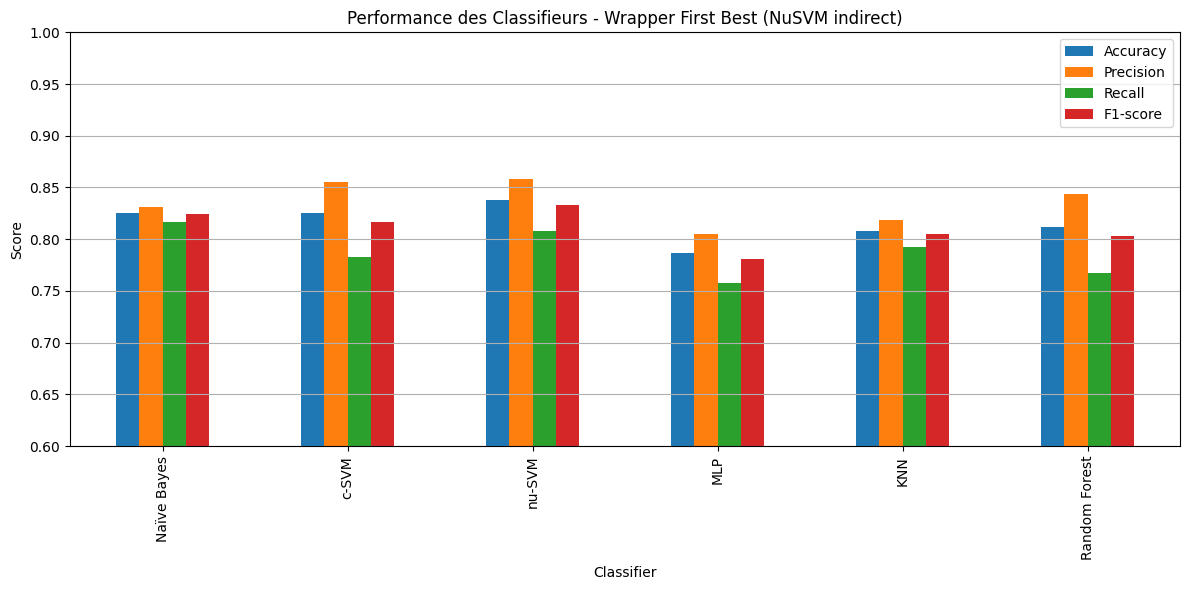

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector

# Étape 1 – Sélection avec un modèle stable (Random Forest)
rf_selector_model = RandomForestClassifier(n_estimators=100, random_state=42)
selector = SequentialFeatureSelector(rf_selector_model, direction='forward', cv=5, n_jobs=-1)
X_selected = selector.fit_transform(X_scaled, y)
selected_columns = selector.get_support(indices=True)

print(f"Nombre de features sélectionnées : {X_selected.shape[1]}")

# Étape 2 – Évaluation finale avec NuSVC (et les autres)
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "c-SVM": SVC(kernel="rbf", C=1.0),
    "nu-SVM": NuSVC(nu=0.5, kernel="rbf"),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for name, clf in classifiers.items():
    y_pred = cross_val_predict(clf, X_selected, y, cv=cv)
    results.append({
        "Classifier": name,
        "Accuracy": round(accuracy_score(y, y_pred), 3),
        "Precision": round(precision_score(y, y_pred), 3),
        "Recall": round(recall_score(y, y_pred), 3),
        "F1-score": round(f1_score(y, y_pred), 3)
    })

# Résumé
results_df = pd.DataFrame(results)
print("\nRésumé des performances :")
display(results_df)
import matplotlib.pyplot as plt

results_df.set_index("Classifier")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs - Wrapper First Best (NuSVM indirect)")
plt.ylabel("Score")
plt.ylim(0.6, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()



greedy stepwise

Nombre de features sélectionnées : 22

Résumé des performances :


,Classifier,Accuracy,Precision,Recall,F1-score
0,Naïve Bayes,0.812,0.815,0.808,0.812
1,c-SVM,0.833,0.851,0.808,0.829
2,nu-SVM,0.833,0.839,0.825,0.832
3,MLP,0.783,0.788,0.775,0.782
4,KNN,0.821,0.829,0.808,0.819
5,Random Forest,0.812,0.844,0.767,0.803


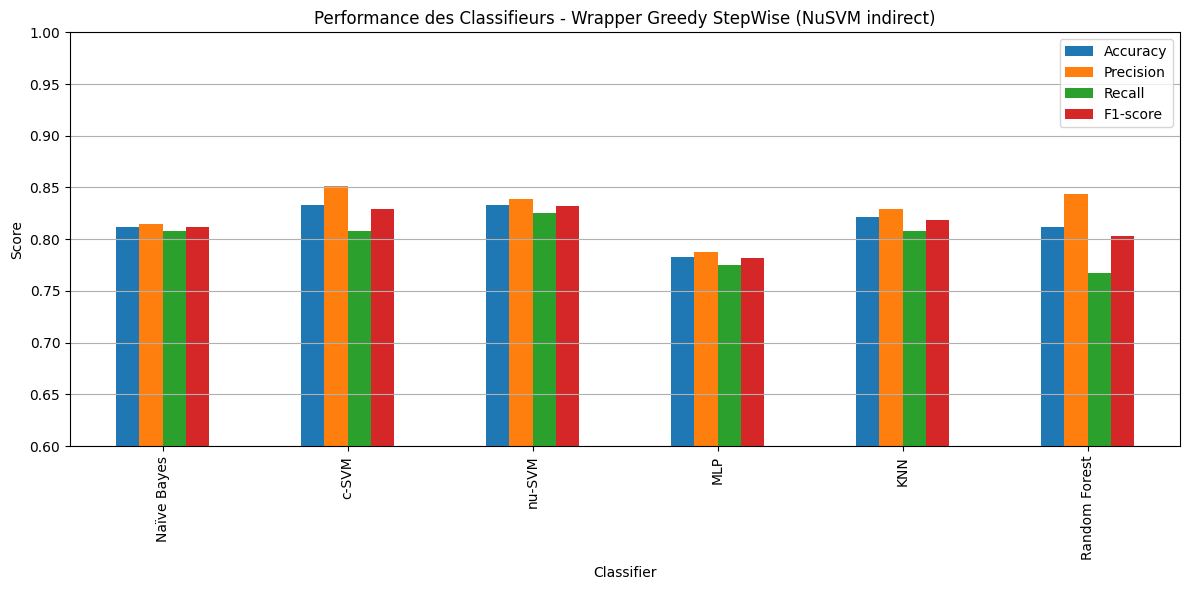

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector

# Étape 1 – Sélection avec un modèle stable (Random Forest)
rf_selector_model = RandomForestClassifier(n_estimators=100, random_state=42)
selector = SequentialFeatureSelector(rf_selector_model, direction='backward', cv=5, n_jobs=-1)
X_selected = selector.fit_transform(X_scaled, y)
selected_columns = selector.get_support(indices=True)

print(f"Nombre de features sélectionnées : {X_selected.shape[1]}")

# Étape 2 – Évaluation finale avec NuSVC (et les autres)
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "c-SVM": SVC(kernel="rbf", C=1.0),
    "nu-SVM": NuSVC(nu=0.5, kernel="rbf"),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for name, clf in classifiers.items():
    y_pred = cross_val_predict(clf, X_selected, y, cv=cv)
    results.append({
        "Classifier": name,
        "Accuracy": round(accuracy_score(y, y_pred), 3),
        "Precision": round(precision_score(y, y_pred), 3),
        "Recall": round(recall_score(y, y_pred), 3),
        "F1-score": round(f1_score(y, y_pred), 3)
    })

# Résumé
results_df = pd.DataFrame(results)
print("\nRésumé des performances :")
display(results_df)
import matplotlib.pyplot as plt

results_df.set_index("Classifier")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs - Wrapper Greedy StepWise (NuSVM indirect)")
plt.ylabel("Score")
plt.ylim(0.6, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()



PSO

[I 2025-06-20 12:42:51,857] A new study created in memory with name: no-name-67846bd8-b9e1-4cc5-9043-1ba8d0bd185d
[I 2025-06-20 12:42:51,877] Trial 0 finished with value: 0.8166666666666667 and parameters: {'f0': True, 'f1': False, 'f2': False, 'f3': True, 'f4': True, 'f5': False, 'f6': True, 'f7': False, 'f8': True, 'f9': False, 'f10': True, 'f11': False, 'f12': True, 'f13': False, 'f14': False, 'f15': False, 'f16': True, 'f17': False, 'f18': True, 'f19': False, 'f20': True, 'f21': True, 'f22': True, 'f23': True, 'f24': False, 'f25': True, 'f26': True, 'f27': True, 'f28': False, 'f29': True, 'f30': False, 'f31': True, 'f32': False, 'f33': False, 'f34': True, 'f35': True, 'f36': True, 'f37': True, 'f38': False, 'f39': True, 'f40': False, 'f41': True, 'f42': False, 'f43': False}. Best is trial 0 with value: 0.8166666666666667.
[I 2025-06-20 12:42:51,905] Trial 1 finished with value: 0.7875 and parameters: {'f0': True, 'f1': True, 'f2': False, 'f3': True, 'f4': False, 'f5': False, 'f6': 

Nombre de features sélectionnées avec PSO : 21


,Classifier,Accuracy,Precision,Recall,F1-score
0,Naïve Bayes,0.833,0.845,0.817,0.831
1,c-SVM,0.854,0.876,0.825,0.850
2,nu-SVM,0.854,0.883,0.817,0.848
3,MLP,0.779,0.782,0.775,0.778
4,KNN,0.850,0.862,0.833,0.847
5,Random Forest,0.808,0.825,0.783,0.803


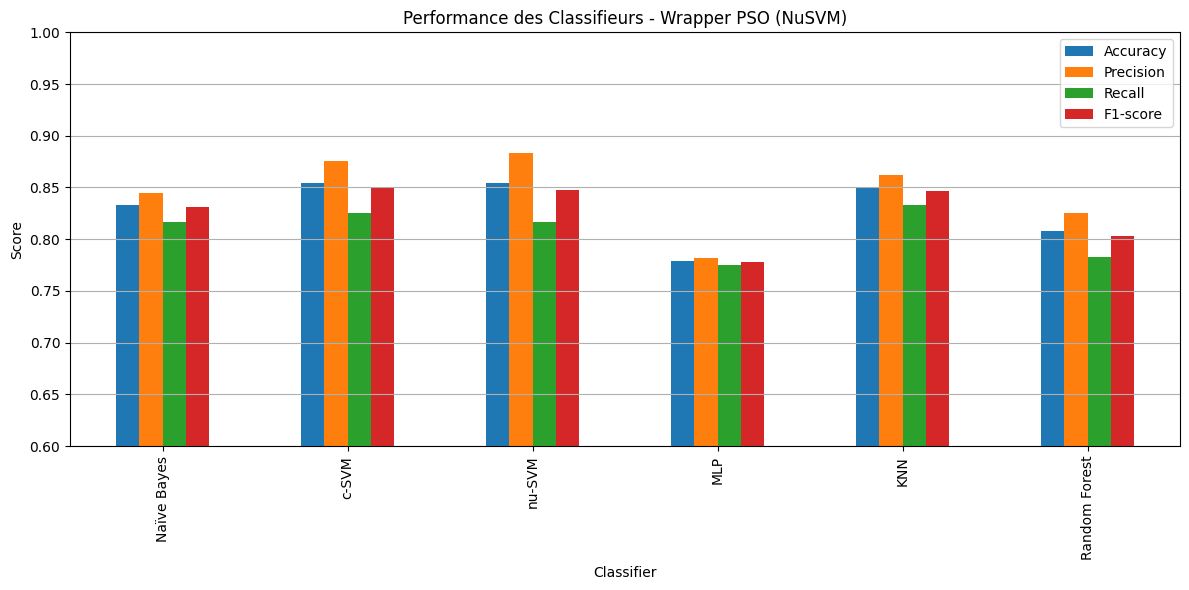

In [17]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import NuSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Chargement et préparation
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=["ID", "Recording", "Status"])
y = df["Status"]

# Encodage binaire
X = pd.get_dummies(X, columns=["Gender"], drop_first=True)

# Supprimer colonnes constantes
X = VarianceThreshold(threshold=1e-6).fit_transform(X)

# Normalisation
scaler = PowerTransformer()
X_scaled = scaler.fit_transform(X)
n_features = X_scaled.shape[1]

# PSO-like avec Optuna
def objective(trial):
    selected = [trial.suggest_categorical(f"f{i}", [True, False]) for i in range(n_features)]
    if not any(selected):
        return 0.0
    X_sub = X_scaled[:, selected]
    clf = NuSVC(nu=0.5, kernel='rbf')
    return cross_val_score(clf, X_sub, y, cv=5, scoring='accuracy').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, timeout=300)

# Application des features sélectionnées
best_features = [v for k, v in study.best_params.items()]
X_selected = X_scaled[:, best_features]
print(f"Nombre de features sélectionnées avec PSO : {sum(best_features)}")

# Évaluation des classifieurs
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "c-SVM": SVC(kernel="rbf"),
    "nu-SVM": NuSVC(nu=0.5, kernel="rbf"),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for name, clf in classifiers.items():
    y_pred = cross_val_predict(clf, X_selected, y, cv=cv)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
   
    results.append({
        "Classifier": name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-score": round(f1, 3)
    })

# Résultats en tableau
results_df = pd.DataFrame(results)

# Affichage tableau
from IPython.display import display
display(results_df)

# Graphique comparatif
results_df.set_index("Classifier")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs - Wrapper PSO (NuSVM)")
plt.ylabel("Score")
plt.ylim(0.6, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
